In [1]:
# Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load Dataset

In [4]:
df = pd.read_csv("uber.csv")

In [5]:
# Basic Data Exploration

In [6]:
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   trip_id  driver_id  rider_id           city  pickup_lat  pickup_lng  \
0        1       8270     10683  San Francisco   37.170931  -77.586479   
1        2       1860     44743         Boston   38.898127 -108.582977   
2        3       6390     75839  San Francisco   38.814571  -89.942603   
3        4       6191     22189       New York   37.295906  -75.328844   
4        5       6734     61104        Seattle   38.972395 -121.482913   

    drop_lat    drop_lng  distance_km  fare_amount     status payment_method  \
0  37.173652  -77.619934         2.97        10.71  Completed         Wallet   
1  38.937464 -108.558727         8.43        22.41  Completed            UPI   
2  38.821702  -89.896435         5.46        12.91  Completed           Cash   
3  37.301375  -75.317488         6.61        15.70  Completed         Wallet   
4  38.992088 -121.467904        10.50        19.15  Completed         Wallet   

           pickup_time                      drop_time  
0  2

In [8]:
# Data Cleaning
# Drop Missing Value

In [9]:
df = df.dropna()

In [10]:
# Convert pickup datetime

In [21]:
df['pickup_time'] = pd.to_datetime(df['pickup_time'])

In [14]:
# Remove invalid fare values

In [15]:
df = df[df['fare_amount'] > 0]

In [16]:
# Feature Engineering

In [19]:
df['hour'] = df['pickup_time'].dt.hour
df['day'] = df['pickup_time'].dt.day_name()
df['month'] = df['pickup_time'].dt.month

In [22]:
#  Basic Analysis

In [23]:
print("\nAverage Fare:", df['fare_amount'].mean())

print("\nTrips by Hour:")
print(df['hour'].value_counts().sort_index())

print("\nTrips by Day:")
print(df['day'].value_counts())


Average Fare: 15.963656829936111

Trips by Hour:
hour
0     1260
1     1260
2     1260
3     1260
4     1260
5     1260
6     1260
7     1260
8     1260
9     1260
10    1260
11    1260
12    1260
13    1203
14    1200
15    1200
16    1200
17    1200
18    1200
19    1200
20    1200
21    1200
22    1200
23    1200
Name: count, dtype: int64

Trips by Day:
day
Sunday       4320
Monday       4320
Tuesday      4320
Wednesday    4320
Thursday     4320
Friday       4320
Saturday     3663
Name: count, dtype: int64


In [24]:
#  Visualization
# Set style

In [25]:
sns.set(style="whitegrid")

In [26]:
# 📊 Trips by Hour

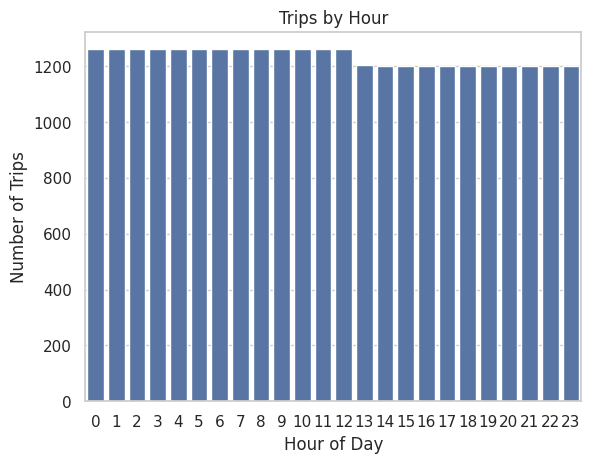

In [27]:
plt.figure()
sns.countplot(x='hour', data=df)
plt.title("Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

In [28]:
# 📊 Trips by Day

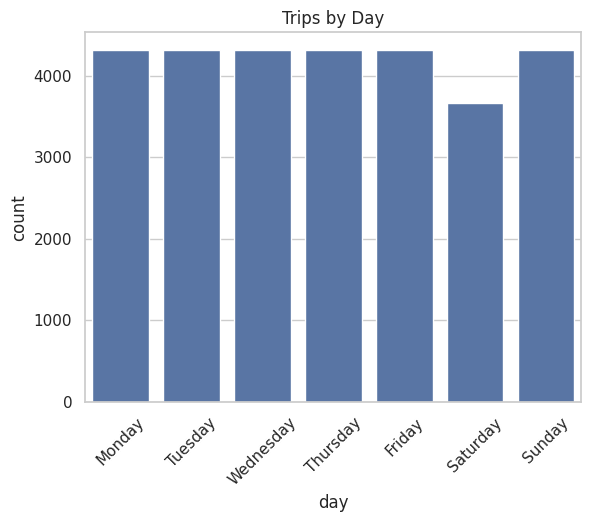

In [29]:
plt.figure()
sns.countplot(x='day', data=df, order=[
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
plt.title("Trips by Day")
plt.xticks(rotation=45)
plt.show()

In [30]:
# 📈 Fare Distribution

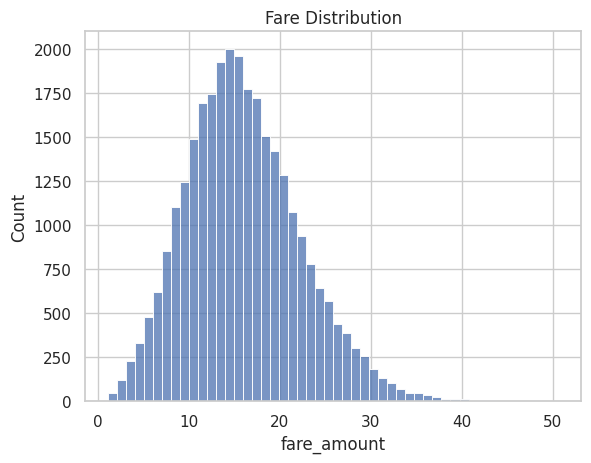

In [31]:
plt.figure()
sns.histplot(df['fare_amount'], bins=50)
plt.title("Fare Distribution")
plt.show()


In [32]:
# 📉 Distance vs Fare

In [33]:
if 'trip_distance' in df.columns:
    plt.figure()
    sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
    plt.title("Distance vs Fare")
    plt.show()


In [34]:
# 🔥 Heatmap (Correlation)

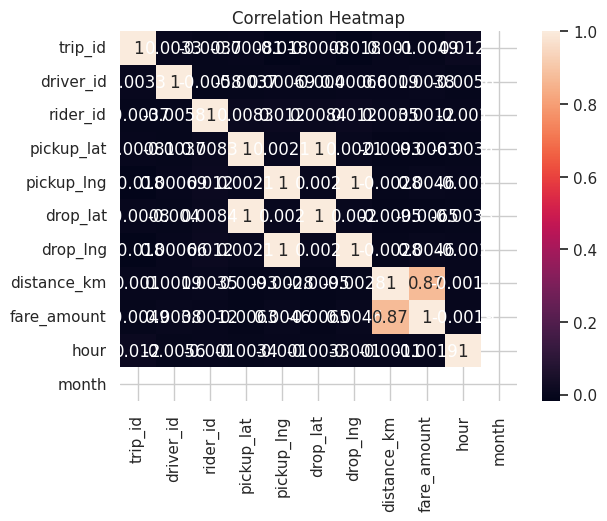

In [35]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [36]:
# Insights (Print Key Findings)

In [37]:
print("\n🔍 Insights:")
print("- Peak hours are:", df['hour'].value_counts().idxmax())
print("- Most rides happen on:", df['day'].value_counts().idxmax())
print("- Average fare is:", round(df['fare_amount'].mean(), 2))


🔍 Insights:
- Peak hours are: 0
- Most rides happen on: Sunday
- Average fare is: 15.96
